In [ ]:
import os

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam

import wandb
from wandb.integration.keras import WandbMetricsLogger

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np

In [ ]:
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(5)

In [2]:
lr = 1e-3
epochs = 100
batch_size = 128 ## reduce to 64 to reduce overfitting

# Transfer learning

## MobileNetV2

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [ ]:
# Convert labels to one-hot vectors
# # Visualize some examples
class_names = [
  'airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog' ,
  'frog' ,
  'horse',
  'ship',
  'truck'
  ]

num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

In [ ]:
# Convert to numpy and preprocess for MobileNetV2
X_train_scaled = preprocess_input(X_train)
X_test_scaled = preprocess_input(X_test)

In [ ]:
### Resize the image to prepare for MobileNetV2: the closest to 224 the better
X_train_resized = tf.image.resize(X_train_scaled, (112, 112))
X_test_resized = tf.image.resize(X_test_scaled, (112, 112))

In [4]:
# Build transfer learning model
base_model = MobileNetV2(input_shape=(112, 112, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base

/tmp/ipykernel_5981/2731605378.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(112, 112, 3), include_top=False, weights='imagenet')
I0000 00:00:1771579277.791908    5981 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [ ]:
# from tensorflow.keras import layers, models
model_transfer = Sequential([
    base_model,
    GlobalAveragePooling2D(), 
    Dense(128, activation='relu'), 
    Dense(10, activation='softmax') 
])

opt = Adam(learning_rate=lr)

### Freeze the base

In [8]:
### Compile the model
model_transfer.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train_resized) ##X_train_resized X_train

# Setup EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  
    patience=10,           
    restore_best_weights=True
)


In [ ]:
# !wandb login

In [ ]:
### Group account
name = "MobileNetV2Model_freeze112_Norm"

wandb.init(
    entity="Ironhack_cnn_project",                  
    project="cifar10_dataset_FantasticFour",  
    name= name,
    config={                   
        "epochs": epochs,
        "batch_size": batch_size,
        "optimizer": "adam",
        "learning_rate": lr,
        "augmentation": True
    }
)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: eya-cherif14 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# Train with WandbCallback
model_transfer.fit(
    datagen.flow(X_train_resized, y_train_cat, batch_size=batch_size, shuffle=True),
    epochs=epochs,
    validation_data=(X_test_resized, y_test_cat),
    callbacks=[
        early_stopping,
        WandbMetricsLogger(log_freq="epoch")  # logs everything!
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
 41/391 ━━━━━━━━━━━━━━━━━━━━ 1:55 331ms/step - accuracy: 0.4138 - loss: 1.8445

In [ ]:
### Evaluation
train_loss, train_acc = model_transfer.evaluate(datagen.flow(X_train_resized, y_train_cat, batch_size=batch_size), verbose=0)
test_loss, test_acc = model_transfer.evaluate(X_test_resized, y_test_cat, verbose=0)

# Log summary table to wandb
wandb.log({
    "summary_table": wandb.Table(
        columns=["Split", "Loss", "Accuracy"],
        data=[
            ["Train", round(train_loss, 4), round(train_acc, 4)],
            ["Test/Val", round(test_loss, 4), round(test_acc, 4)]
        ]
    )
})

In [ ]:
# ---- SAVE ----
## Store locally
# ### Mount the drive
# from google.colab import drive
# drive.mount('/content/drive')

model_transfer.save(f"{name}.keras")

In [ ]:
## Store to wandb
artifact = wandb.Artifact(name=f"{name}", type="model")
artifact.add_file(f"{name}.keras")
wandb.log_artifact(artifact)


# Mark run as finished
wandb.finish()

#### Evaluation

In [ ]:
# # ---- LOAD later (any machine, any teammate!) ----
# import wandb
# wandb.init(entity="fantastic-four", project="cifar10_dataset_FantasticFour")

# artifact = wandb.use_artifact("fantastic-four/cifar10_dataset_FantasticFour/cifar10-model:latest")
# artifact_dir = artifact.download()    # downloads to local folder

# import tensorflow as tf
# model_transfer = tf.keras.models.load_model(f"{artifact_dir}/my_model.keras")

In [ ]:
# Predict class probabilities
y_pred_probs = model_transfer.predict(X_test_resized)
# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
# y_pred = model_deeper.predict(X_test).argmax(axis=1)

y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

In [ ]:
# Predict & confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Make sure y_pred and y_true are numpy arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Convert X_test to numpy if it's a TensorFlow tensor
X_test_np = X_test.numpy() if hasattr(X_test, 'numpy') else X_test

# Confusing class pairs to inspect
confusing_pairs = [
    (6, 0),  # Shirt vs T-shirt/top
    (4, 2),  # Coat vs Pullover
    (4, 6)   # Coat vs Shirt
]

# Function to plot misclassified images between two specific classes
def show_confusion_examples(y_true, y_pred, X, class1, class2, n=5):
    # Find indices of images where class1 was confused with class2 and vice versa
    idx_confused_1 = np.where((y_true == class1) & (y_pred == class2))[0]
    idx_confused_2 = np.where((y_true == class2) & (y_pred == class1))[0]

    fig, axes = plt.subplots(2, n, figsize=(15, 5))
    fig.suptitle(f"Confusions: {class_names[class1]} ↔ {class_names[class2]}", fontsize=16)

    for i in range(n):
        if i < len(idx_confused_1):
            ax = axes[0, i]
            ax.imshow(X[idx_confused_1[i]])
            # plt.imshow(X_train[i], cmap='gray')
            ax.set_title(f"True: {class_names[class1]}\nPred: {class_names[class2]}")
            ax.axis('off')
        else:
            axes[0, i].axis('off')

        if i < len(idx_confused_2):
            ax = axes[1, i]
            ax.imshow(X[idx_confused_2[i]], cmap='gray')
            ax.set_title(f"True: {class_names[class2]}\nPred: {class_names[class1]}")
            ax.axis('off')
        else:
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Show misclassifications for each confusing pair
for class1, class2 in confusing_pairs:
    show_confusion_examples(y_true, y_pred, X_test_np, class1, class2)


### Unfreeze the base

In [ ]:
# Unfreeze last layers of base model for fine-tuning
base_model.trainable = True

# Freeze all layers except the last N (e.g., last 20% layers)
fine_tune_at = int(len(base_model.layers)*0.8)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile model with a lower learning rate
model_transfer.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

# Setup EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',   # metric to monitor
    patience=10,           # stop if no improvement after n epochs
    restore_best_weights=True
)

In [ ]:
# !wandb login

In [ ]:
### Group account
name = "MobileModel_unfreeze112_Norm"

wandb.init(
    entity="Ironhack_cnn_project",                  
    project="cifar10_dataset_FantasticFour",  
    name= name,
    config={                    
        "epochs": epochs,
        "batch_size": batch_size,
        "optimizer": "adam",
        "learning_rate": lr,
        "augmentation": True
    }
)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: eya-cherif14 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
### Train the model
model_transfer.fit(
    datagen.flow(X_train_resized, y_train_cat, batch_size=batch_size, shuffle=True), ##X_train_resized X_train
    epochs= epochs,
    validation_data=(X_test_resized, y_test_cat),
    callbacks=[
        early_stopping,
        WandbMetricsLogger(log_freq="epoch")  # logs everything!
    ]
)


In [ ]:
### Evaluation the model
train_loss, train_acc = model_transfer.evaluate(datagen.flow(X_train_resized, y_train_cat, batch_size=batch_size), verbose=0)
test_loss, test_acc = model_transfer.evaluate(X_test_resized, y_test_cat, verbose=0)

# Log summary table to wandb
wandb.log({
    "summary_table": wandb.Table(
        columns=["Split", "Loss", "Accuracy"],
        data=[
            ["Train", round(train_loss, 4), round(train_acc, 4)],
            ["Test/Val", round(test_loss, 4), round(test_acc, 4)]
        ]
    )
})

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 214s 467ms/step - accuracy: 0.7829 - loss: 0.6485 - val_accuracy: 0.5772 - val_loss: 3.8313
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 0.8786 - loss: 0.3556 - val_accuracy: 0.7757 - val_loss: 1.4256
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 0.8981 - loss: 0.2954 - val_accuracy: 0.6045 - val_loss: 3.8785
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 0.9095 - loss: 0.2628 - val_accuracy: 0.5346 - val_loss: 4.6665
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 344ms/step - accuracy: 0.9191 - loss: 0.2372 - val_accuracy: 0.5682 - val_loss: 3.5494
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 344ms/step - accuracy: 0.9221 - loss: 0.2250 - val_accuracy: 0.7883 - val_loss: 1.4077
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 344ms/step - accuracy: 0.9264 - loss: 0.2088 - val_accuracy: 0.6961 - val_loss: 2.0597
Epoch 8/100
388/391 ━━━━━━━━━━━━━━━━━━━━ 1s 339ms/step - accuracy: 0.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ---- SAVE ----
## Store locally
model_transfer.save(f"{name}.keras")

In [ ]:
## Store to wandb
artifact = wandb.Artifact(name=f"{name}", type="model")
artifact.add_file(f"{name}.keras")
wandb.log_artifact(artifact)

# Mark run as finished
wandb.finish()

epoch/accuracy,▁▄▅▅▅▆▆▆▇▇▇▇▇██████
epoch/epoch,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
epoch/val_accuracy,▁▂▁▆▆▆▅▇██▇█▇█▇███▇
epoch/val_loss,█▇█▂▃▂▄▂▁▁▁▁▁▁▂▂▁▁▂
epoch/accuracy,0.95826
epoch/epoch,18
epoch/learning_rate,0.001
epoch/loss,0.11832
epoch/val_accuracy,0.8774


#### Evaluation

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()


# # Convert labels to one-hot vectors
# num_classes = 10 #len(class_names)
# y_train_cat = to_categorical(y_train, num_classes=num_classes)
# y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Convert to numpy and preprocess for MobileNetV2
X_train_scaled = preprocess_input(X_train)
X_test_scaled = preprocess_input(X_test)

### Resize the image to prepare for MobileNetV2: the closest to 224 the better
X_train_resized = tf.image.resize(X_train_scaled, (112, 112))
X_test_resized = tf.image.resize(X_test_scaled, (112, 112))

In [ ]:
# ---- LOAD later (any machine, any teammate!) ----
wandb.init(entity="Ironhack_cnn_project", project="cifar10_dataset_FantasticFour")

artifact = wandb.use_artifact("Ironhack_cnn_project/cifar10_dataset_FantasticFour/MobileModel_unfreeze112_earlystopping:latest")
artifact_dir = artifact.download()    # downloads to local folder

model_transfer = tf.keras.models.load_model(f"{artifact_dir}/my_model.keras")

# # Or load just the weights
# model_transfer.load_weights("MobileModel_unfreeze112_Norm.keras")
# model_transfer

In [ ]:
# Predict class probabilities
y_pred_probs = model_transfer.predict(X_test_resized)
# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
# y_pred = model_deeper.predict(X_test).argmax(axis=1)

y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

In [ ]:
class_names = [
  'airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog' ,
  'frog' ,
  'horse',
  'ship',
  'truck'
  ]

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

In [ ]:
# Predict & confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")        
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

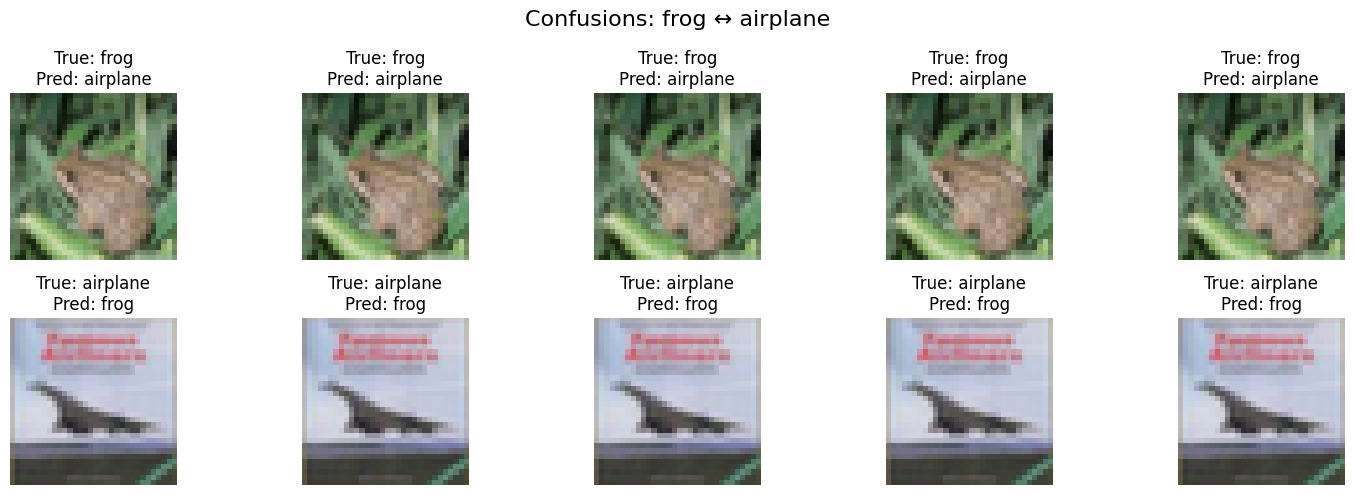

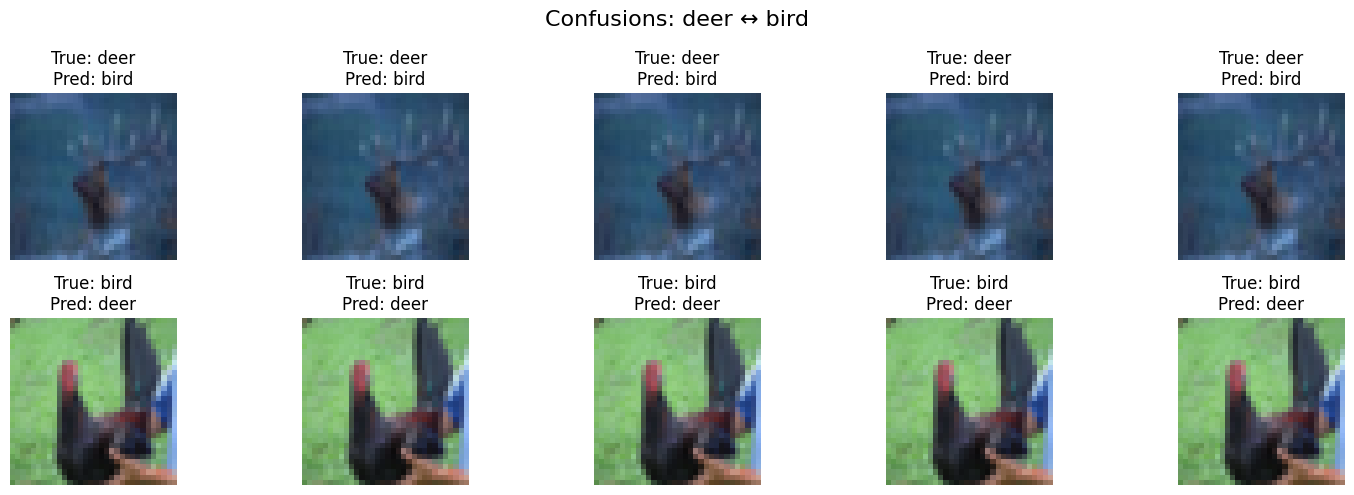

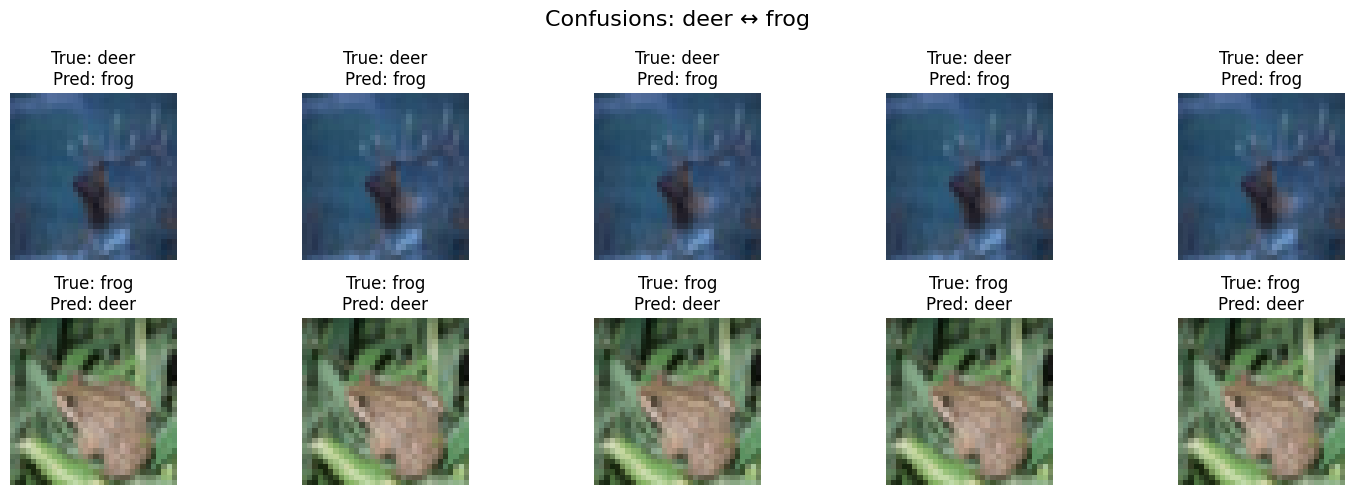

In [ ]:
# Make sure y_pred and y_true are numpy arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Convert X_test to numpy if it's a TensorFlow tensor
X_test_np = X_test.numpy() if hasattr(X_test, 'numpy') else X_test

# Confusing class pairs to inspect
confusing_pairs = [
    (6, 0),  # Shirt vs T-shirt/top
    (4, 2),  # Coat vs Pullover
    (4, 6)   # Coat vs Shirt
]

# Function to plot misclassified images between two specific classes
def show_confusion_examples(y_true, y_pred, X, class1, class2, n=5):
    # Find indices of images where class1 was confused with class2 and vice versa
    idx_confused_1 = np.where((y_true == class1) & (y_pred == class2))[0]
    idx_confused_2 = np.where((y_true == class2) & (y_pred == class1))[0]

    fig, axes = plt.subplots(2, n, figsize=(15, 5))
    fig.suptitle(f"Confusions: {class_names[class1]} ↔ {class_names[class2]}", fontsize=16)

    for i in range(n):
        if i < len(idx_confused_1):
            ax = axes[0, i]
            ax.imshow(X[idx_confused_1[i]])
            # plt.imshow(X_train[i], cmap='gray')
            ax.set_title(f"True: {class_names[class1]}\nPred: {class_names[class2]}")
            ax.axis('off')
        else:
            axes[0, i].axis('off')

        if i < len(idx_confused_2):
            ax = axes[1, i]
            ax.imshow(X[idx_confused_2[i]], cmap='gray')
            ax.set_title(f"True: {class_names[class2]}\nPred: {class_names[class1]}")
            ax.axis('off')
        else:
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Show misclassifications for each confusing pair
for class1, class2 in confusing_pairs:
    show_confusion_examples(y_true, y_pred, X_test_np, class1, class2)
